<a href="https://colab.research.google.com/github/AnanyaAsthana/Digital-Image-Processing/blob/main/DIP_LAB_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-image

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

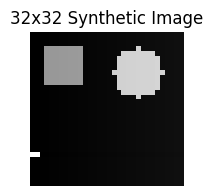

In [ ]:
# very small image
img = np.zeros((32,32), dtype=np.uint8)

# rectangle
cv2.rectangle(img,(3,3),(10,10),150,-1)

# circle
cv2.circle(img,(22,8),5,200,-1)

# line
cv2.line(img,(0,25),(32,25),255,1)

# gradient
for i in range(32):
    img[:,i] = img[:,i] + i//2

img = np.clip(img,0,255)

# make display smaller
plt.figure(figsize=(2,2))

plt.imshow(img,cmap='gray')
plt.title("32x32 Synthetic Image")
plt.axis("off")

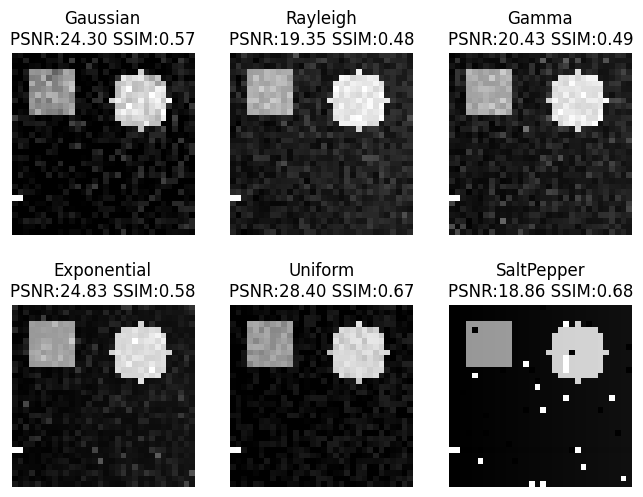

In [ ]:
noises = {
"Gaussian": gaussian_noise(img),
"Rayleigh": rayleigh_noise(img),
"Gamma": gamma_noise(img),
"Exponential": exponential_noise(img),
"Uniform": uniform_noise(img),
"SaltPepper": salt_pepper(img)
}

plt.figure(figsize=(8,6))

for i,(name,nimg) in enumerate(noises.items()):

    psnr = peak_signal_noise_ratio(img,nimg)
    ssim = structural_similarity(img,nimg)

    plt.subplot(2,3,i+1)
    plt.imshow(nimg,cmap='gray')
    plt.title(f"{name}\nPSNR:{psnr:.2f} SSIM:{ssim:.2f}")
    plt.axis("off")

plt.show()

In [ ]:
def gaussian_noise(image):
    noise = np.random.normal(0,20,image.shape)
    noisy = image + noise
    return np.clip(noisy,0,255).astype(np.uint8)

def rayleigh_noise(image):
    noise = np.random.rayleigh(20,image.shape)
    noisy = image + noise
    return np.clip(noisy,0,255).astype(np.uint8)

def gamma_noise(image):
    noise = np.random.gamma(2,10,image.shape)
    noisy = image + noise
    return np.clip(noisy,0,255).astype(np.uint8)

def exponential_noise(image):
    noise = np.random.exponential(10,image.shape)
    noisy = image + noise
    return np.clip(noisy,0,255).astype(np.uint8)

def uniform_noise(image):
    noise = np.random.uniform(-20,20,image.shape)
    noisy = image + noise
    return np.clip(noisy,0,255).astype(np.uint8)

def salt_pepper(image,prob=0.02):
    noisy = np.copy(image)

    salt = np.random.rand(*image.shape) < prob
    pepper = np.random.rand(*image.shape) < prob

    noisy[salt] = 255
    noisy[pepper] = 0

    return noisy

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

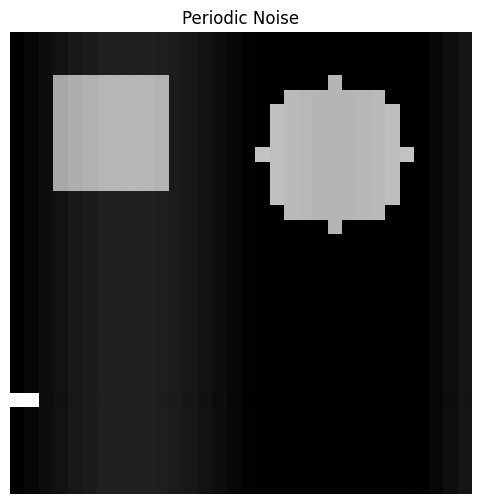

In [ ]:
rows,cols = img.shape

x = np.arange(cols)
y = np.arange(rows)

X,Y = np.meshgrid(x,y)

periodic = 30*np.sin(2*np.pi*X/30)

noisy_periodic = img + periodic
noisy_periodic = np.clip(noisy_periodic,0,255).astype(np.uint8)
plt.figure(figsize=(8,6))
plt.imshow(noisy_periodic,cmap='gray')
plt.title("Periodic Noise")
plt.axis("off")

In [ ]:
def butterworth_bandreject(shape,D0,W,n=2):

    rows,cols = shape
    crow,ccol = rows//2 , cols//2

    H = np.zeros((rows,cols))

    for u in range(rows):
        for v in range(cols):

            D = np.sqrt((u-crow)**2 + (v-ccol)**2)

            if D == D0:
                H[u,v] = 0
            else:
                H[u,v] = 1/(1 + ((D*W)/(D**2-D0**2))**(2*n))

    return H

/tmp/ipykernel_186/1081148789.py:12: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr = peak_signal_noise_ratio(img,img_back)


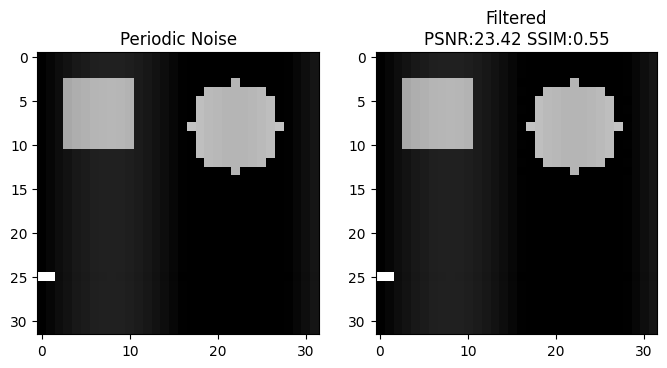

In [ ]:
f = np.fft.fft2(noisy_periodic)
fshift = np.fft.fftshift(f)

H = butterworth_bandreject(img.shape,40,10)

filtered = fshift*H

ishift = np.fft.ifftshift(filtered)
img_back = np.fft.ifft2(ishift)
img_back = np.abs(img_back)

psnr = peak_signal_noise_ratio(img,img_back)
ssim = structural_similarity(img,img_back.astype(np.uint8))

plt.figure(figsize=(8,6))

plt.subplot(121)
plt.imshow(noisy_periodic,cmap='gray')
plt.title("Periodic Noise")

plt.subplot(122)
plt.imshow(img_back,cmap='gray')
plt.title(f"Filtered\nPSNR:{psnr:.2f} SSIM:{ssim:.2f}")

plt.show()

In [ ]:
noisy = gaussian_noise(img)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

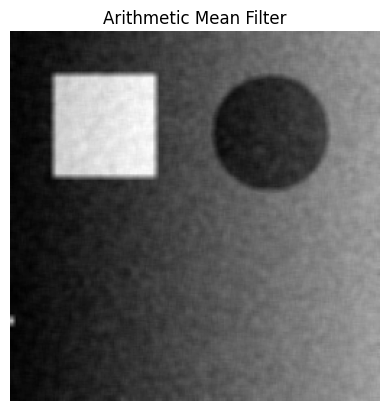

In [ ]:
arith = cv2.blur(noisy,(5,5))

plt.imshow(arith,cmap='gray')
plt.title("Arithmetic Mean Filter")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

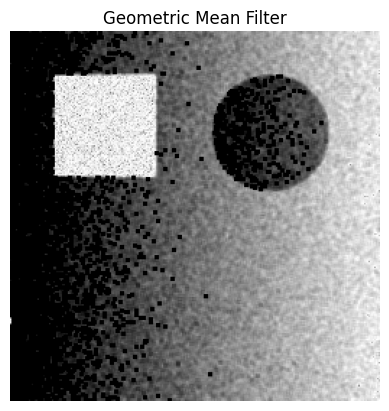

In [ ]:
def geometric_filter(img,k=3):

    pad = k//2
    padded = np.pad(img,pad,'reflect')
    output = np.zeros_like(img,dtype=float)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            window = padded[i:i+k,j:j+k]
            output[i,j] = np.prod(window)**(1/(k*k))

    return output

geo = geometric_filter(noisy)

plt.imshow(geo,cmap='gray')
plt.title("Geometric Mean Filter")
plt.axis("off")

/tmp/ipykernel_186/2386948474.py:11: RuntimeWarning: divide by zero encountered in divide
  output[i,j] = (k*k)/np.sum(1/(window+1))


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

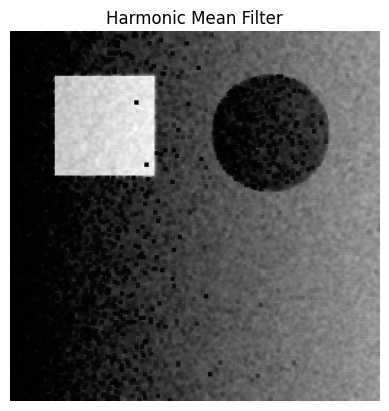

In [ ]:
def harmonic_filter(img,k=3):

    pad = k//2
    padded = np.pad(img,pad,'reflect')
    output = np.zeros_like(img,dtype=float)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            window = padded[i:i+k,j:j+k]
            output[i,j] = (k*k)/np.sum(1/(window+1))

    return output

harm = harmonic_filter(noisy)

plt.imshow(harm,cmap='gray')
plt.title("Harmonic Mean Filter")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

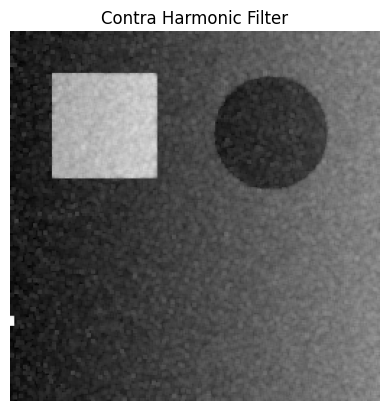

In [ ]:
def contraharmonic_filter(img,Q=1.5,k=3):

    pad = k//2
    padded = np.pad(img,pad,'reflect')
    output = np.zeros_like(img,dtype=float)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            window = padded[i:i+k,j:j+k]

            num = np.sum(window**(Q+1))
            den = np.sum(window**Q)

            output[i,j] = num/(den+1)

    return output

contra = contraharmonic_filter(noisy)

plt.imshow(contra,cmap='gray')
plt.title("Contra Harmonic Filter")
plt.axis("off")

In [ ]:
sp = salt_pepper(img)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

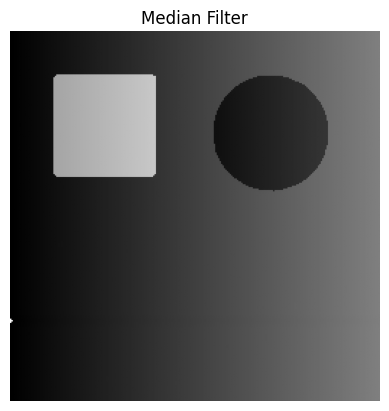

In [ ]:
median = cv2.medianBlur(sp,5)

plt.imshow(median,cmap='gray')
plt.title("Median Filter")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

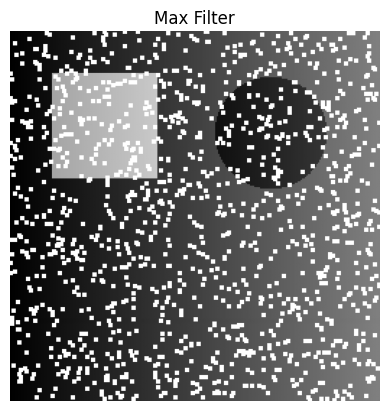

In [ ]:
maxf = cv2.dilate(sp,np.ones((3,3)))

plt.imshow(maxf,cmap='gray')
plt.title("Max Filter")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

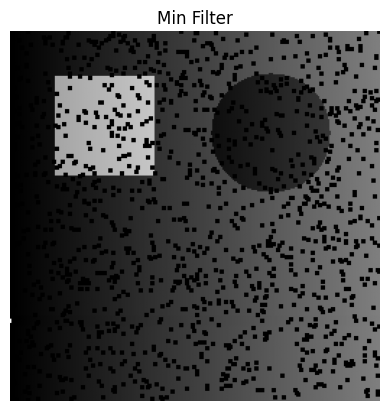

In [ ]:
minf = cv2.erode(sp,np.ones((3,3)))

plt.imshow(minf,cmap='gray')
plt.title("Min Filter")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

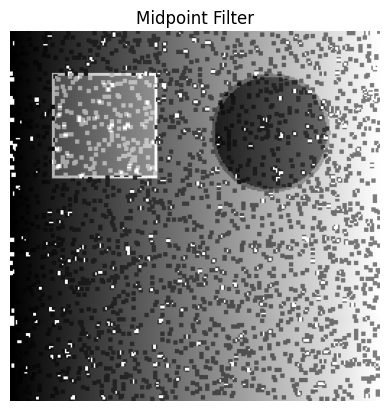

In [ ]:
mid = (maxf + minf)/2

plt.imshow(mid,cmap='gray')
plt.title("Midpoint Filter")
plt.axis("off")